In [1]:
import numpy as np
import pickle
import math
from scipy.stats import sem
import matplotlib.pyplot as plt
import pandas as pd
import time
import pprint
import seaborn as sns
import statsmodels.formula.api as smf
import CMR_IA as cmr
import scipy as sp
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, get_wmse

In [2]:
try:
    plt.rcParams["font.family"] = "Times New Roman"
except:
    from matplotlib import font_manager

    font_manager.fontManager.addfont("/home1/beigejin/Times.ttc")
    plt.rc("font", family="serif", serif=["Times"])
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.rm"] = "Times"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu4_data/simu4_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
# df_study = df_study.loc[df_study.session < 100]  # for testing
# df_test = df_test.loc[df_test.session < 100]  # for testing

In [4]:
df_study

,itemno1,item,itemno_old,freq,quantile,session,list,itemno2
0,316,FARM,552,1161,8,0,0,-1
1,477,LEOPARD,812,118,3,0,0,-1
2,433,INSTRUCTOR,741,78,2,0,0,-1
3,87,BOTTLE,153,1479,8,0,0,-1
4,84,BOOT,150,149,3,0,0,-1
...,...,...,...,...,...,...,...,...
99995,895,TOWN,1491,3328,9,999,0,-1
99996,633,PIANO,1057,466,6,999,0,-1
99997,843,SUBMARINE,1398,154,3,999,0,-1
99998,462,LABYRINTH,791,32,0,999,0,-1


In [5]:
df_test

,itemno1,item,itemno_old,freq,quantile,session,list,position,old,itemno2
0,341,FORT,595,411,6,0,0,0,True,-1
1,512,MANSION,864,156,3,0,0,1,True,-1
2,66,BENCH,121,345,6,0,0,2,True,-1
3,386,GUARD,667,658,7,0,0,3,False,-1
4,57,BEE,112,185,4,0,0,4,True,-1
...,...,...,...,...,...,...,...,...,...,...
199995,503,LUNG,850,169,4,999,0,195,True,-1
199996,891,TORNADO,1485,34,0,999,0,196,False,-1
199997,932,VEHICLE,1553,383,6,999,0,197,False,-1
199998,735,RUG,1215,321,5,999,0,198,True,-1


In [6]:
sem_mat = np.load("simu4_data/simu4_smat.npy")

## Run CMR-IA

In [7]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, use_flexible_thresh=True)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="4ctrl")
optim_params = np.loadtxt("simu4_data/4ctrl_250502_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.33443,
 'beta_rec': 0.5,
 'beta_cue': 0.999697,
 'beta_rec_post': 0.5,
 'beta_distract': 0.275197,
 'phi_s': 2,
 'phi_d': 0.5,
 's_cf': 0,
 's_fc': 8e-06,
 'kappa': 0.5,
 'eta': 0.5,
 'omega': 5,
 'alpha': 1,
 'lamb': 0.5,
 'c_thresh': 0.5,
 'c_thresh_itm': 0.910843,
 'c_thresh_assoc': 0.5,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.623447,
 'gamma_cf': 0.5,
 'use_flexible_thresh': True,
 'thresh_rate': 9.996005}

In [8]:
if SAVERES:
    # run the model
    df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat)
    # merge to get more info
    df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
    # save
    df_simu.to_pickle("simu4_data/simu4_result_ctrl.pkl")
else:
    # load the results
    df_simu = pd.read_pickle("simu4_data/simu4_result_ctrl.pkl")
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,item,itemno_old,freq,quantile,position,old
0,0,0,341,-1,0,0,0.005485,5.078566e-02,0.488677,FORT,595,411,6,0,True
1,0,0,512,-1,1,0,0.017808,4.998222e-03,0.503202,MANSION,864,156,3,1,True
2,0,0,66,-1,0,0,0.015592,1.621977e-02,0.499843,BENCH,121,345,6,2,True
3,0,0,386,-1,0,0,0.000008,1.420237e-02,0.496451,GUARD,667,658,7,3,False
4,0,0,57,-1,1,0,0.004141,7.771008e-06,0.501033,BEE,112,185,4,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,999,0,503,-1,1,0,0.000008,4.961475e-07,0.500002,LUNG,850,169,4,195,True
199996,999,0,891,-1,0,0,0.000007,7.101055e-06,0.500000,TORNADO,1485,34,0,196,False
199997,999,0,932,-1,0,0,0.000004,6.236863e-06,0.499999,VEHICLE,1553,383,6,197,False
199998,999,0,735,-1,1,0,0.000021,3.366068e-06,0.500004,RUG,1215,321,5,198,True


## Analysis

In [9]:
df_simu.groupby(["old"]).s_resp.mean()

old
False    0.16144
True     0.87665
Name: s_resp, dtype: float64

In [10]:
# get wordfreq quantile
with open("simu4_data/simu4_word_freq.pkl", "rb") as inp:
    df = pickle.load(inp)
df

,item,itemno_old,itemno,freq,quantile
0,ABDOMEN,1,1,110,2
1,ACROBAT,4,2,17,0
2,ADULT,8,3,906,8
3,ALLEY,15,4,165,4
4,ALLIGATOR,16,5,12,0
...,...,...,...,...,...
979,YOKE,1632,980,12,0
980,YOLK,1633,981,47,1
981,YOUTH,1634,982,1159,8
982,ZIPPER,1636,983,24,0


In [11]:
# check mean frequency of each group
freq_mean = df.groupby("quantile").freq.mean().to_numpy()
freq_mean = np.around(freq_mean, decimals=0)
freq_mean

array([  21.,   51.,   90.,  141.,  196.,  284.,  415.,  632., 1163.,
       4332.])

### Csim

In [12]:
# check the recognition threshold for each group
s_mean = np.mean(sem_mat, axis=1)
c_vec_cal = params["c_s"] * s_mean + params["c_thresh_itm"]
df["c_vec"] = c_vec_cal
df.groupby("quantile").c_vec.mean()

quantile
0    0.910843
1    0.910843
2    0.910843
3    0.910843
4    0.910843
5    0.910843
6    0.910843
7    0.910843
8    0.910843
9    0.910843
Name: c_vec, dtype: float64

In [13]:
# separate hf and lf
create_level = {0: "new lf", 1: "new hf", 2: "old lf", 3: "old hf"}
df_simu["hf"] = df_simu["quantile"] >= 5
df_simu["level"] = df_simu.apply(lambda x: create_level[x["old"] * 2 + x["hf"]], axis=1)
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,item,itemno_old,freq,quantile,position,old,hf,level
0,0,0,341,-1,0,0,0.005485,5.078566e-02,0.488677,FORT,595,411,6,0,True,True,old hf
1,0,0,512,-1,1,0,0.017808,4.998222e-03,0.503202,MANSION,864,156,3,1,True,False,old lf
2,0,0,66,-1,0,0,0.015592,1.621977e-02,0.499843,BENCH,121,345,6,2,True,True,old hf
3,0,0,386,-1,0,0,0.000008,1.420237e-02,0.496451,GUARD,667,658,7,3,False,True,new hf
4,0,0,57,-1,1,0,0.004141,7.771008e-06,0.501033,BEE,112,185,4,4,True,False,old lf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,999,0,503,-1,1,0,0.000008,4.961475e-07,0.500002,LUNG,850,169,4,195,True,False,old lf
199996,999,0,891,-1,0,0,0.000007,7.101055e-06,0.500000,TORNADO,1485,34,0,196,False,False,new lf
199997,999,0,932,-1,0,0,0.000004,6.236863e-06,0.499999,VEHICLE,1553,383,6,197,False,True,new hf
199998,999,0,735,-1,1,0,0.000021,3.366068e-06,0.500004,RUG,1215,321,5,198,True,True,old hf


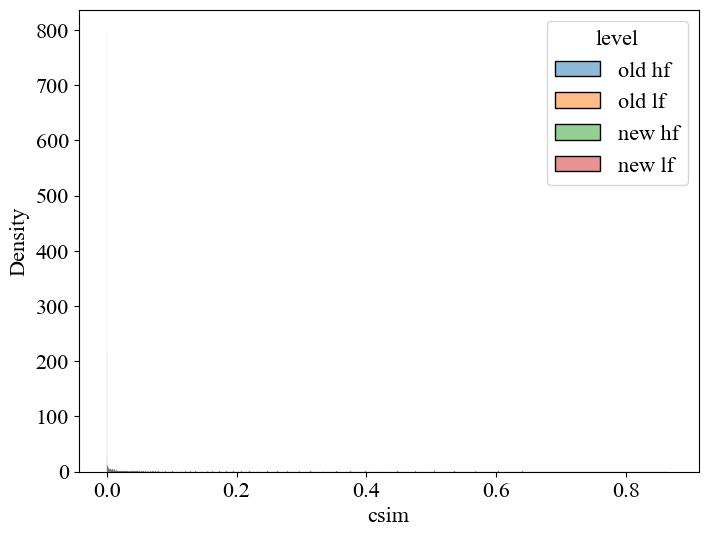

In [14]:
# plot the csim distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(df_simu, x="csim", hue="level", alpha=0.5, ax=ax, stat="density")
plt.show()

In [15]:
# check the csim of each group
df_tmp = df_simu.groupby(["old", "quantile"]).csim.mean().to_frame().reset_index()
df_tmp = pd.pivot_table(data=df_tmp, values="csim", columns="old", index="quantile").reset_index()
df_tmp["True-False"] = df_tmp[True] - df_tmp[False]
df_tmp["thresh"] = df_simu.groupby("quantile").thresh.mean()
df_tmp

old,quantile,False,True,True-False,thresh
0,0,0.000005,0.088784,0.088780,0.039203
1,1,0.000005,0.091765,0.091760,0.040438
2,2,0.000005,0.088519,0.088514,0.041735
3,3,0.000005,0.090399,0.090395,0.041061
4,4,0.000005,0.087747,0.087742,0.041044
5,5,0.000005,0.089397,0.089392,0.040720
6,6,0.000005,0.087911,0.087906,0.040973
7,7,0.000004,0.087119,0.087115,0.040324
8,8,0.000004,0.090539,0.090534,0.041281
9,9,0.000004,0.087871,0.087867,0.039935


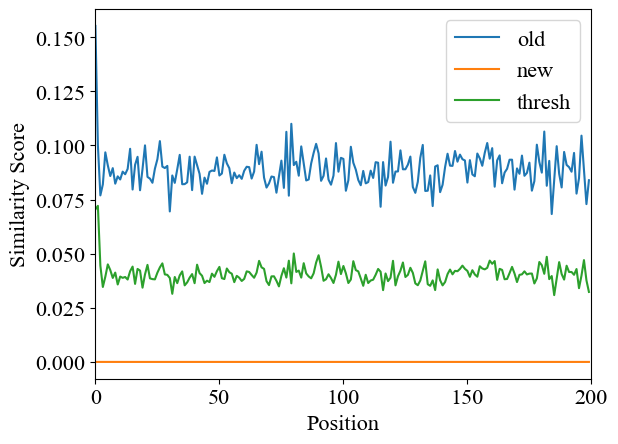

In [16]:
old_csim_pos = df_simu.query("old == True").groupby("position").csim.mean()
old_pos = np.unique(df_simu.query("old == True").position.to_numpy())
new_csim_pos = df_simu.query("old == False").groupby("position").csim.mean()
new_pos = np.unique(df_simu.query("old == False").position.to_numpy())
cthresh_pos = df_simu.groupby("position").thresh.mean()
pos = np.unique(df_simu.position.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
plt.xlim(0, 200)
plt.show()

### Yes Rate

In [17]:
# session-wise, get yes rate for each condition
df_sess_q = df_simu.groupby(["session", "quantile", "old"]).s_resp.mean().to_frame(name="yes_rate").reset_index()
df_sess_q

,session,quantile,old,yes_rate
0,0,0,False,0.111111
1,0,0,True,0.875000
2,0,1,False,0.153846
3,0,1,True,0.727273
4,0,2,False,0.076923
...,...,...,...,...
19995,999,7,True,0.909091
19996,999,8,False,0.500000
19997,999,8,True,0.818182
19998,999,9,False,0.100000


In [18]:
# collapse across session
df_q = df_sess_q.groupby(["quantile", "old"]).yes_rate.mean().to_frame().reset_index()
df_q

,quantile,old,yes_rate
0,0,False,0.170585
1,0,True,0.879726
2,1,False,0.170957
3,1,True,0.877247
4,2,False,0.167270
5,2,True,0.876362
6,3,False,0.163791
7,3,True,0.876897
8,4,False,0.165809
9,4,True,0.873552


In [19]:
# format df for plotting
df_plot = pd.pivot_table(df_q, values="yes_rate", index="quantile", columns="old").reset_index()
df_plot.rename(columns={False: "far", True: "hr"}, inplace=True)
df_plot["freq_mean"] = freq_mean
df_plot

old,quantile,far,hr,freq_mean
0,0,0.170585,0.879726,21.0
1,1,0.170957,0.877247,51.0
2,2,0.167270,0.876362,90.0
3,3,0.163791,0.876897,141.0
4,4,0.165809,0.873552,196.0
5,5,0.159310,0.884285,284.0
6,6,0.161810,0.870958,415.0
7,7,0.154473,0.875471,632.0
8,8,0.149924,0.871690,1163.0
9,9,0.145637,0.879146,4332.0


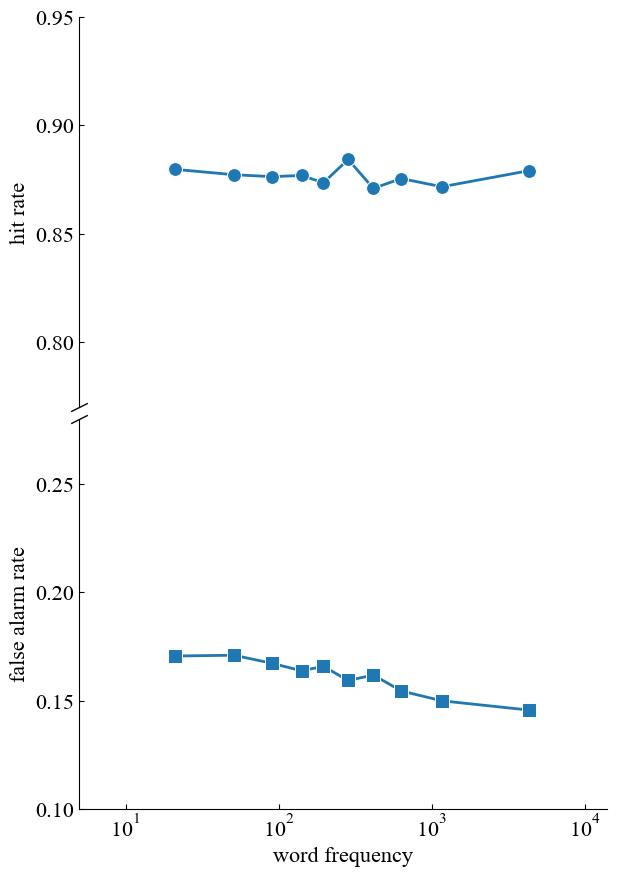

In [20]:
# plot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 9))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
fig.subplots_adjust(hspace=0.03)

sns.lineplot(data=df_plot, y="hr", x="freq_mean", ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
sns.lineplot(data=df_plot, y="far", x="freq_mean", ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

ax1.set_ylim(0.77, 0.95)
ax1.set_yticks(np.arange(0.80, 0.96, 0.05))
ax2.set_ylim(0.1, 0.28)
ax2.set_yticks(np.arange(0.1, 0.30, 0.05))
ax1.tick_params(axis="y", direction="in")
ax1.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.tick_params(axis="x", direction="in")
plt.xscale("log")
plt.xlim(5, 14000)

ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.spines.right.set_visible(False)
ax2.spines.right.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False, labeltop=False)
ax2.minorticks_off()

d = 0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax1.set_ylabel("hit rate")
ax2.set_ylabel("false alarm rate")
ax2.set_xlabel("word frequency")

# plt.tight_layout(h_pad = 0)
if SAVEFIG:
    ax1.set_ylabel(None)
    ax1.set_xlabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    ax1.tick_params(labelleft=False)
    ax2.tick_params(labelleft=False)
    plt.savefig("simu4_fig/simu4_WFE_ctrl.pdf")
plt.show()

### d-prime

In [21]:
# session-wise, get z yes rate for each condition
df_sess_q_adj = df_simu.groupby(["session", "quantile", "old"]).s_resp.aggregate(["sum", "count"]).reset_index()
df_sess_q_adj["yes_rate_adj"] = (df_sess_q_adj["sum"] + 0.5) / (df_sess_q_adj["count"] + 1)
df_sess_q_adj["z_yes_rate"] = sp.stats.norm.ppf(df_sess_q_adj["yes_rate_adj"])
df_sess_q_adj

,session,quantile,old,sum,count,yes_rate_adj,z_yes_rate
0,0,0,False,1,9,0.150000,-1.036433
1,0,0,True,7,8,0.833333,0.967422
2,0,1,False,2,13,0.178571,-0.920823
3,0,1,True,8,11,0.708333,0.548522
4,0,2,False,1,13,0.107143,-1.241867
...,...,...,...,...,...,...,...
19995,999,7,True,10,11,0.875000,1.150349
19996,999,8,False,4,8,0.500000,0.000000
19997,999,8,True,9,11,0.791667,0.812218
19998,999,9,False,1,10,0.136364,-1.096804


In [22]:
# collapse across session
df_q_adj = df_sess_q_adj.groupby(["quantile", "old"]).z_yes_rate.mean().to_frame().reset_index()
df_q_adj = pd.pivot_table(df_q_adj, values="z_yes_rate", index="quantile", columns="old").reset_index()
df_q_adj.rename(columns={False: "z_far", True: "z_hr"}, inplace=True)
df_q_adj["dprime"] = df_q_adj["z_hr"] - df_q_adj["z_far"]
df_q_adj["freq_mean"] = freq_mean
df_q_adj

old,quantile,z_far,z_hr,dprime,freq_mean
0,0,-0.899221,1.089752,1.988974,21.0
1,1,-0.901316,1.080554,1.981870,51.0
2,2,-0.923325,1.083599,2.006924,90.0
3,3,-0.929554,1.078282,2.007835,141.0
4,4,-0.919906,1.064145,1.984050,196.0
5,5,-0.945520,1.116724,2.062244,284.0
6,6,-0.936858,1.054472,1.991330,415.0
7,7,-0.963648,1.074212,2.037860,632.0
8,8,-0.973117,1.057361,2.030478,1163.0
9,9,-0.993584,1.094016,2.087600,4332.0


### Error Check

In [23]:
# load ground truth
with open("simu4_data/simu4_gt.pkl", "rb") as f:
    hr_gt = pickle.load(f)
    hr_std_gt = pickle.load(f)
    far_gt = pickle.load(f)
    far_std_gt = pickle.load(f)
hr_gt, far_gt

(array([0.90287356, 0.88502554, 0.88761973, 0.88043582, 0.87863985,
        0.87963761, 0.86965996, 0.86187739, 0.84172254, 0.83693327]),
 array([0.11368631, 0.13186813, 0.14265734, 0.16373626, 0.17142857,
        0.18301698, 0.18661339, 0.19320679, 0.19150849, 0.19280719]))

In [24]:
hr_std_gt, far_std_gt

(array([0.0058908 , 0.00718391, 0.00688458, 0.00858078, 0.00818167,
        0.01087564, 0.00947877, 0.01032687, 0.01117497, 0.0106262 ]),
 array([0.00689311, 0.00714286, 0.00619381, 0.00574426, 0.00659341,
        0.00784216, 0.00784216, 0.00814186, 0.00809191, 0.01053946]))

In [25]:
# Get behavioral stats and compare with ground truth
hr = df_q.query("old == True")["yes_rate"].to_numpy()
far = df_q.query("old == False")["yes_rate"].to_numpy()
err = get_wmse(hr_gt, hr, hr_std_gt) + get_wmse(far_gt, far, far_std_gt)
err

247.5652573363871

247.5652573363871

### Slope Check

In [26]:
import statsmodels.formula.api as smf
from scipy import stats

In [27]:
sessions = df_sess_q.session.unique()
df_sess_q["freq_mean"] = df_sess_q["quantile"].apply(lambda x: freq_mean[x])
df_sess_q["log_freq_mean"] = np.log(df_sess_q["freq_mean"])
df_sess_q

,session,quantile,old,yes_rate,freq_mean,log_freq_mean
0,0,0,False,0.111111,21.0,3.044522
1,0,0,True,0.875000,21.0,3.044522
2,0,1,False,0.153846,51.0,3.931826
3,0,1,True,0.727273,51.0,3.931826
4,0,2,False,0.076923,90.0,4.499810
...,...,...,...,...,...,...
19995,999,7,True,0.909091,632.0,6.448889
19996,999,8,False,0.500000,1163.0,7.058758
19997,999,8,True,0.818182,1163.0,7.058758
19998,999,9,False,0.100000,4332.0,8.373785


In [28]:
slopes_hr, slopes_far = [], []
for sess in sessions:
    # slope for HR
    df_tmp = df_sess_q.query("session == @sess and old == True").copy()
    res = smf.ols(formula="yes_rate ~ log_freq_mean", data=df_tmp).fit()
    slopes_hr.append(res.params["log_freq_mean"])

    # slope for FAR
    df_tmp = df_sess_q.query("session == @sess and old == False").copy()
    res = smf.ols(formula="yes_rate ~ log_freq_mean", data=df_tmp).fit()
    slopes_far.append(res.params["log_freq_mean"])

In [29]:
np.mean(slopes_hr), np.std(slopes_hr), sem(slopes_hr)

(-0.000513937117686531, 0.024379160682135737, 0.0007713225097061361)

In [30]:
np.mean(slopes_far), np.std(slopes_far), sem(slopes_far)

(-0.005313942042400746, 0.0260194894793156, 0.0008232202161563476)

In [31]:
# t test
t_stat, p_val = stats.ttest_1samp(slopes_hr, 0)
t_stat, p_val

(-0.6663063909315111, 0.5053691181227767)

In [32]:
# t test
t_stat, p_val = stats.ttest_1samp(slopes_far, 0)
t_stat, p_val

(-6.455067475397752, 1.684610237007367e-10)